# Selective prediction with probly

A selective predictor either answers or abstains, based on an uncertainty criterion. This tutorial walks through the `probly.selective_prediction` API on a two-moons toy problem. The test set contains in-distribution points (clean and noisy: aleatoric uncertainty) and out-of-distribution (OOD) points (epistemic uncertainty).

## In short

The whole workflow in one block: transform a model, train it, wrap it in a `SelectivePredictor`, and call it. The sections below go through each step in detail.

In [1]:
import torch
from torch import nn
from sklearn.datasets import make_moons

from probly.selective_prediction import SelectivePredictor, ThresholdSelector
from probly.transformation import dropout

# 1. Transform a plain network into an MC-dropout model and train it as usual
X, y = make_moons(n_samples=500, noise=0.2, random_state=0)
X, y = torch.from_numpy(X).float(), torch.from_numpy(y).long()

torch.manual_seed(0)
net = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
model = dropout(net, p=0.2, predictor_type="logit_classifier")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
model.train()
for _ in range(300):
    optimizer.zero_grad()
    nn.functional.cross_entropy(model(X), y).backward()
    optimizer.step()
model.eval()

# 2. Wrap it: abstain where the model's own error probability exceeds 0.2 (Chow's rule)
selective = SelectivePredictor(model, ThresholdSelector(0.2), representer_kwargs={"num_samples": 50})

x = torch.tensor([[0.0, 1.0], [0.5, 0.25], [3.0, 2.5]])  # inside a moon, between the moons, far away
with torch.no_grad():
    result = selective(x)

print("prediction ", result.decision.probabilities.argmax(dim=-1).tolist())
print("uncertainty", [round(u, 3) for u in result.uncertainty.tolist()])
print("accepted   ", result.accepted.tolist())
print("coverage   ", result.coverage)

prediction  [0, 1, 1]
uncertainty [0.0, 0.481, 0.456]
accepted    [True, False, False]
coverage    0.3333333333333333


In [2]:
from collections import namedtuple
import logging
import sys
from pathlib import Path

# make `examples.utils` importable regardless of the kernel's working directory
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
import torch
from torch import nn

from probly.method.sngp import reset_precision_matrix, sngp
from probly.representer import representer
from probly.selective_prediction import SelectivePredictor, ThresholdSelector
from probly.transformation import dropout, ensemble

from examples.utils.model import MLPClassifier
from examples.utils.plotting import plot_example_uncertainty

BLUE, RED, GRAY, PURPLE, TEAL = "#1e88e5", "#ff0d57", "#7f8c8d", "#9b59b6", "#16a085"
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.25})
# keep the saved notebook small
get_ipython().run_line_magic("config", "InlineBackend.print_figure_kwargs = {'bbox_inches': 'tight', 'dpi': 80}")

## Helpers

Small functions that keep the API calls below uncluttered. `run` applies a selective predictor in batches and returns numpy arrays; the seed is fixed per batch, so every predictor draws the same MC samples and all figures and tables show the same predictions.

In [3]:
NOTIONS = ["total", "aleatoric", "epistemic"]
VARIANTS = ["normal", *NOTIONS]
NUM_SAMPLES = 50
# Fixed thresholds per notion, on the scale of the default zero-one loss.
THRESHOLDS = {"total": 0.2, "aleatoric": 0.2, "epistemic": 0.05}
Result = namedtuple("Result", "pred uncertainty accepted")


def make_selective(model, notion="total", threshold=0.2):
    # Ensembles are evaluated member by member; the other models are sampled.
    kwargs = {} if isinstance(model, nn.ModuleList) else {"num_samples": NUM_SAMPLES}
    return SelectivePredictor(model, ThresholdSelector(threshold), notion=notion, representer_kwargs=kwargs)


def run(predictor, x, batch=1000):
    # Returns the predicted class, the uncertainty, and the acceptance mask as numpy arrays.
    parts = []
    for i in range(0, len(x), batch):
        torch.manual_seed(0)
        xb = torch.as_tensor(x[i : i + batch]).float()
        with torch.no_grad():
            r = predictor(xb)
        parts.append((r.decision.probabilities.argmax(-1).numpy(), r.uncertainty.numpy(), r.accepted.numpy()))
    return Result(*(np.concatenate(p) for p in zip(*parts, strict=True)))


def evaluate(models, sets, thresholds=THRESHOLDS):
    # ONE selective pass per model and notion over every test set. Everything below reuses these results.
    results = {}
    for name, model in models.items():
        for notion in NOTIONS:
            predictor = make_selective(model, notion, thresholds[notion])
            results[name, notion] = {s: run(predictor, x) for s, x in sets.items()}
    return results


def as_normal(res):
    # Normal prediction: the same predictions, but nothing is rejected.
    return {s: r._replace(accepted=np.ones_like(r.accepted)) for s, r in res.items()}


def mistakes(res, labels):
    # Wrong labels among accepted labeled points, plus accepted OOD points (always a mistake: no true label).
    wrong = sum(((r.pred != labels[s]) & r.accepted).sum() for s, r in res.items() if s in labels)
    ood = sum(r.accepted.sum() for s, r in res.items() if s not in labels)
    return int(wrong), int(ood)


def summary_table(results, labels):
    rows = []
    for (name, notion), res in results.items():
        pred = np.concatenate([res[s].pred for s in labels])
        acc = np.concatenate([res[s].accepted for s in labels])
        y = np.concatenate(list(labels.values()))
        wrong, ood = mistakes(res, labels)
        rows.append(
            {"model": name, "notion": notion, "threshold": THRESHOLDS[notion]}
            | {f"cov {s}": r.accepted.mean() for s, r in res.items()}
            | {f"acc {s} (normal)": (res[s].pred == labels[s]).mean() for s in labels}
            | {"acc accepted": (pred == y)[acc].mean(), "mistakes": wrong + ood}
        )
    return pd.DataFrame(rows).set_index(["model", "notion"])


def plot_coverage(results, colors):
    names = list(dict.fromkeys(n for n, _ in results))
    fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 3.8), sharey=True)
    for ax, name in zip(axes, names, strict=True):
        subsets = list(results[name, "total"])
        for k, s in enumerate(subsets):
            ax.bar(np.arange(3) + (k - 1) * 0.27, [results[name, n][s].accepted.mean() for n in NOTIONS], 0.27, color=colors[s], label=s)
        ax.set_xticks(range(3), NOTIONS)
        ax.set_title(name)
        ax.set_xlabel("selection notion")
    axes[0].set_ylabel("coverage")
    axes[0].set_ylim(0, 1.2)
    axes[0].legend(loc="upper left", ncol=3)
    plt.tight_layout()
    plt.show()


def plot_mistakes(results, labels):
    # Stacked bars: wrong labels (in-distribution) + accepted OOD points, normal vs selective.
    names = list(dict.fromkeys(n for n, _ in results))
    fig, ax = plt.subplots(figsize=(13, 4.5))
    for g, name in enumerate(names):
        for v, variant in enumerate(VARIANTS):
            res = as_normal(results[name, "total"]) if variant == "normal" else results[name, variant]
            wrong, ood = mistakes(res, labels)
            x = g * 5 + v
            ax.bar(x, wrong, color=RED, label="wrong label (clean + noisy)" if (g, v) == (0, 0) else None)
            ax.bar(x, ood, bottom=wrong, color=PURPLE, label="accepted OOD point" if (g, v) == (0, 0) else None)
            ax.text(x, wrong + ood, f"{wrong + ood}", ha="center", va="bottom", fontsize=9)
    ax.set_xticks([g * 5 + v for g in range(len(names)) for v in range(4)],
                  [v for _ in names for v in VARIANTS], fontsize=8)
    for g, name in enumerate(names):
        ax.text(g * 5 + 1.5, -0.2, name, transform=ax.get_xaxis_transform(), ha="center", va="top", fontweight="bold")
    ax.set_ylabel("mistakes")
    ax.set_title("Mistakes = wrong labels + accepted OOD points (normal vs selective)")
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.legend(loc="upper center", ncol=2)
    plt.tight_layout()
    plt.show()


def plot_acc_cov(results, labels):
    names = list(dict.fromkeys(n for n, _ in results))
    y = np.concatenate(list(labels.values()))
    fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 4.2), sharey=True)
    for ax, name in zip(axes, names, strict=True):
        for notion, color in zip(NOTIONS, [BLUE, PURPLE, TEAL], strict=True):
            res = results[name, notion]
            pred = np.concatenate([res[s].pred for s in labels])
            u = np.concatenate([res[s].uncertainty for s in labels])
            acc = np.concatenate([res[s].accepted for s in labels])
            hit = (pred == y)[np.argsort(u, kind="stable")]
            n = np.arange(1, len(hit) + 1)
            ax.plot(n / len(hit), np.cumsum(hit) / n, color=color, label=notion)
            ax.scatter(acc.mean(), (pred == y)[acc].mean(), color=color, zorder=3, s=40)
        ax.axhline((pred == y).mean(), color="black", linestyle="--", label="normal prediction")
        ax.set_title(name)
        ax.set_xlabel("coverage")
        ax.set_xlim(0, 1)
    axes[0].set_ylabel("accuracy on accepted")
    axes[0].legend(loc="lower left")
    plt.tight_layout()
    plt.show()

## Two moons: data

Training labels are coin flips inside the dashed disc (aleatoric). Test sets: clean, noisy (inside the disc), and an OOD ring (epistemic).

In [4]:
PATCH_CENTER, PATCH_RADIUS = np.array([-0.75, 0.65]), 0.4


def in_patch(x):
    return np.linalg.norm(x - PATCH_CENTER, axis=1) < PATCH_RADIUS


def moons_with_noise(n, seed):
    # Moons whose labels are coin flips inside the patch.
    x, y = make_moons(n_samples=n, noise=0.15, random_state=seed)
    rng = np.random.default_rng(seed)
    y = np.where(in_patch(x), rng.integers(0, 2, n), y)
    return x, y


X_train, y_train = moons_with_noise(800, seed=0)

# test sets: many fresh moon points, split by location relative to the patch
X_pool, y_pool = make_moons(n_samples=6000, noise=0.15, random_state=2)
d = np.linalg.norm(X_pool - PATCH_CENTER, axis=1)
X_clean, y_clean = X_pool[d > PATCH_RADIUS + 0.15][:600], y_pool[d > PATCH_RADIUS + 0.15][:600]
X_noisy = X_pool[d < PATCH_RADIUS][:200]
y_noisy = np.random.default_rng(3).integers(0, 2, len(X_noisy))

angles = np.random.default_rng(4).uniform(0, 2 * np.pi, 300)
X_ood = np.c_[0.5 + 2.6 * np.cos(angles), 0.25 + 2.1 * np.sin(angles)]
X_ood += np.random.default_rng(5).normal(scale=0.2, size=X_ood.shape)

print(f"train {len(X_train)}, clean {len(X_clean)}, noisy {len(X_noisy)}, OOD {len(X_ood)}")

train 800, clean 600, noisy 200, OOD 300


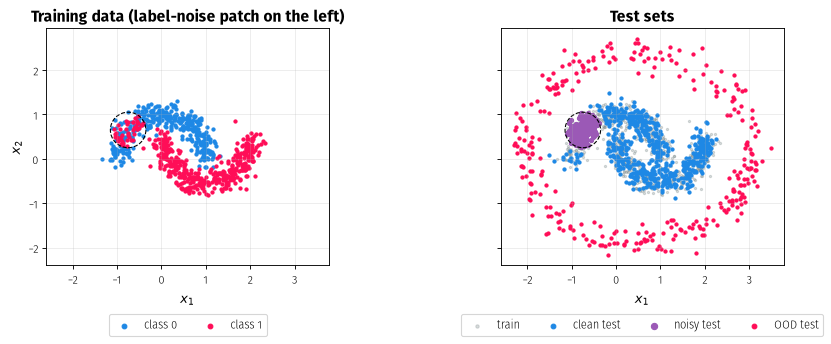

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
ax = axes[0]
ax.scatter(*X_train[y_train == 0].T, c=BLUE, s=8, label="class 0")
ax.scatter(*X_train[y_train == 1].T, c=RED, s=8, label="class 1")
ax.set_title("Training data (label-noise patch on the left)")
ax = axes[1]
ax.scatter(*X_train.T, c=GRAY, s=4, alpha=0.3, label="train")
ax.scatter(*X_clean.T, c=BLUE, s=8, label="clean test")
ax.scatter(*X_noisy.T, c=PURPLE, s=14, label="noisy test")
ax.scatter(*X_ood.T, c=RED, s=8, label="OOD test")
ax.set_title("Test sets")
for ax in axes:
    ax.add_patch(plt.Circle(PATCH_CENTER, PATCH_RADIUS, fill=False, color="black", linestyle="--"))
    ax.set_xlabel("$x_1$")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, markerscale=1.5)
    ax.set_aspect("equal")
axes[0].set_ylabel("$x_2$")
plt.tight_layout()
plt.show()

## Step 1: transform a model and train it

Wrap any network with a probly transformation, then train it as usual.

In [6]:
Xt = torch.from_numpy(X_train).float()
yt = torch.from_numpy(y_train).long()


def fit(module, epochs, lr=1e-2):
    opt = torch.optim.Adam(module.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        nn.functional.cross_entropy(module(Xt), yt).backward()
        opt.step()


# MC dropout
torch.manual_seed(0)
mc_dropout = dropout(MLPClassifier(), p=0.2, predictor_type="logit_classifier", shared_mask=True)
mc_dropout.train()
fit(mc_dropout, 600)
mc_dropout.eval()

# Deep ensemble
torch.manual_seed(0)
deep_ensemble = ensemble(MLPClassifier(), num_members=5, reset_params=True, predictor_type="logit_classifier")
deep_ensemble.train()
for member in deep_ensemble:
    fit(member, 400)
deep_ensemble.eval()

ModuleList(
  (0-4): 5 x MLPClassifier(
    (net): Sequential(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=2, bias=True)
    )
  )
)

In [7]:
class SmallResNet(nn.Module):
    # Same structure as examples.utils.model.ResFFN, with 4 instead of 12 residual blocks.
    def __init__(self, hidden=64, blocks=4):
        super().__init__()
        self.first = nn.Linear(2, hidden)
        self.layers = nn.ModuleList(
            nn.Sequential(nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU()) for _ in range(blocks)
        )
        self.last = nn.Linear(hidden, 2)

    def forward(self, x):
        x = torch.relu(self.first(x))
        for layer in self.layers:
            x = x + layer(x)
        return self.last(x)


torch.manual_seed(0)
sngp_model = sngp(SmallResNet(), num_random_features=128, ridge_penalty=0.01, norm_multiplier=0.9, n_power_iterations=1)
opt = torch.optim.Adam(sngp_model.parameters(), lr=1e-3)
sngp_model.train()
for _ in range(400):
    reset_precision_matrix(sngp_model)
    logits, _ = sngp_model(Xt)
    opt.zero_grad()
    nn.functional.cross_entropy(logits, yt).backward()
    opt.step()
reset_precision_matrix(sngp_model)
with torch.no_grad():
    sngp_model(Xt)  # one pass to accumulate the precision matrix
sngp_model.eval()

models = {"MC dropout": mc_dropout, "Deep ensemble": deep_ensemble, "SNGP": sngp_model}

## Step 2: wrap it in a `SelectivePredictor`

`SelectivePredictor(model, ThresholdSelector(t), representer_kwargs=...)` is called like the model. It returns a `SelectivePrediction` with the `decision`, the `uncertainty` criterion, and the `accepted` mask. Sampling models such as MC dropout need `num_samples`.

In [8]:
sp = SelectivePredictor(mc_dropout, ThresholdSelector(0.2), representer_kwargs={"num_samples": 50})
x = torch.tensor([[0.0, 1.0], [1.0, 0.3], [-0.75, 0.65], [3.0, 2.5]])  # clean, boundary, noise patch, far away
with torch.no_grad():
    result = sp(x)

print("decision   ", result.decision.probabilities.argmax(-1).tolist(), "(argmax of result.decision)")
print("uncertainty", result.uncertainty.numpy().round(3).tolist())
print("accepted   ", result.accepted.tolist())
print("coverage   ", result.coverage)

decision    [0, 0, 0, 1] (argmax of result.decision)
uncertainty [0.0010000000474974513, 0.010999999940395355, 0.4790000021457672, 0.0]
accepted    [True, True, False, True]
coverage    0.75


## Step 3: choose the criterion

`notion` selects what to reject: `"total"` (the default, recommended), `"aleatoric"` (ambiguous inputs), or `"epistemic"` (unfamiliar inputs). `loss` is the task loss that defines the decomposition: the default zero-one loss gives total $=1-\max_k \bar\theta_k$, and `LogLoss()` gives entropy, expected entropy, and mutual information.

```python
SelectivePredictor(model, selector, notion="epistemic", loss=LogLoss())
```

Below we keep the default zero-one loss. The maps (`plot_example_uncertainty`) show the log-loss decomposition: all three notions for MC dropout, then the total for the other two models.

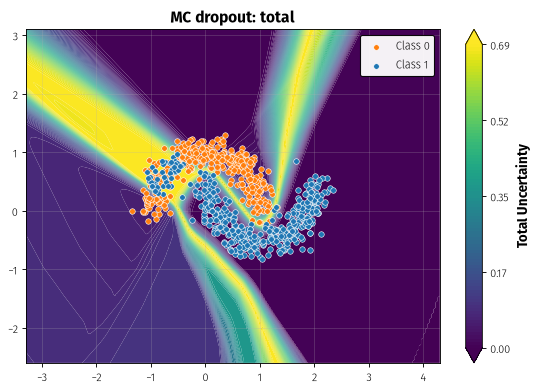

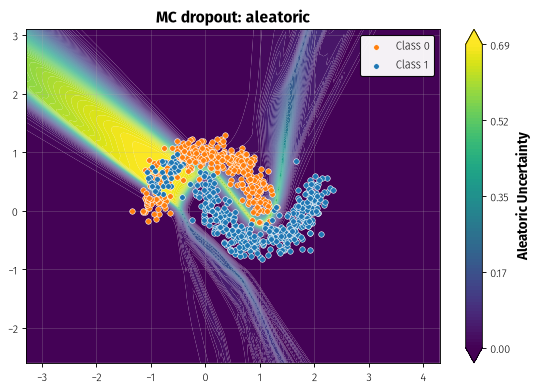

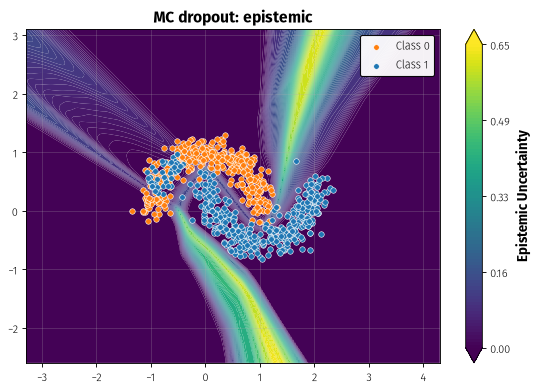

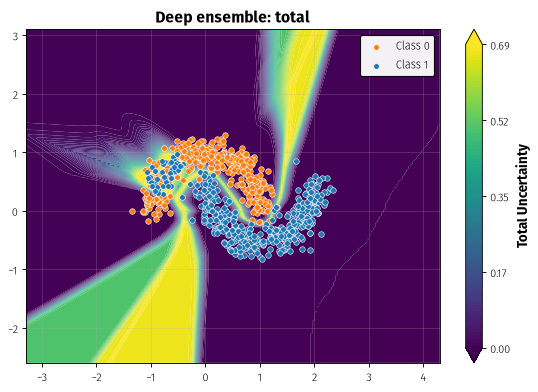

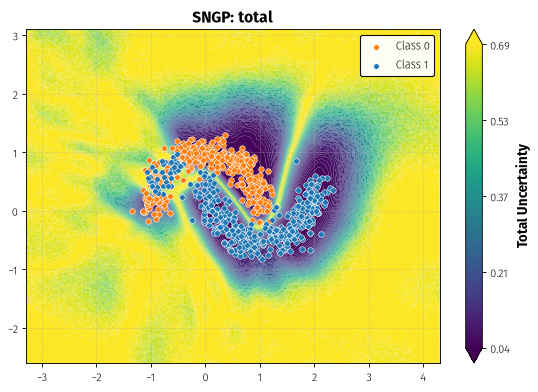

In [9]:
XLIM, YLIM = (-3.3, 4.3), (-2.6, 3.1)
maps = [("MC dropout", n) for n in NOTIONS] + [("Deep ensemble", "total"), ("SNGP", "total")]
for name, notion in maps:
    rep = representer(models[name], **({} if isinstance(models[name], nn.ModuleList) else {"num_samples": 50}))
    plot_example_uncertainty(X_train, y_train, rep, title=f"{name}: {notion}", notion=notion, xlim=XLIM, ylim=YLIM).show()

## Step 4: choose the threshold

With the default zero-one loss, `ThresholdSelector(c)` on the total uncertainty is Chow's rule: abstain where the model's own error probability exceeds the abstention cost `c`. A smaller `c` abstains more.

In [10]:
sets = {"clean": X_clean, "noisy": X_noisy, "OOD": X_ood}
labels = {"clean": y_clean, "noisy": y_noisy}  # OOD points have no label

for c in [0.05, 0.1, 0.2, 0.3]:
    chow = SelectivePredictor(mc_dropout, ThresholdSelector(c), representer_kwargs={"num_samples": 50})
    print(f"c={c:.2f}  coverage", {s: round(float(run(chow, x).accepted.mean()), 2) for s, x in sets.items()})

c=0.05  coverage {'clean': 0.94, 'noisy': 0.0, 'OOD': 0.78}
c=0.10  coverage {'clean': 0.96, 'noisy': 0.0, 'OOD': 0.87}
c=0.20  coverage {'clean': 0.98, 'noisy': 0.01, 'OOD': 0.91}
c=0.30  coverage {'clean': 0.99, 'noisy': 0.06, 'OOD': 0.94}


## Step 5 (optional): a `Selector` on precomputed scores

A `Selector` only sees an array of uncertainty values, so it also works with scores from any model, e.g. one minus the maximum probability of a plain classifier.

In [11]:
with torch.no_grad():
    probs = torch.softmax(deep_ensemble[0](torch.from_numpy(X_clean).float()), dim=-1)
scores = 1 - probs.max(dim=-1).values  # precomputed scores of a single member
accepted = ThresholdSelector(0.2)(scores)
print(f"coverage of ThresholdSelector(0.2) on a single member: {accepted.float().mean():.2f}")

coverage of ThresholdSelector(0.2) on a single member: 0.99


## Evaluation: normal vs selective prediction


In [12]:
results = evaluate(models, sets)
summary_table(results, labels).round(3)

threshold  cov clean  cov noisy  cov OOD  \
model         notion                                                
MC dropout    total           0.20      0.983      0.010    0.907   
              aleatoric       0.20      0.983      0.010    0.953   
              epistemic       0.05      0.993      0.960    0.867   
Deep ensemble total           0.20      0.993      0.055    0.883   
              aleatoric       0.20      0.993      0.055    1.000   
              epistemic       0.05      1.000      0.960    0.860   
SNGP          total           0.20      0.980      0.065    0.113   
              aleatoric       0.20      0.980      0.065    0.113   
              epistemic       0.05      1.000      1.000    0.523   

                         acc clean (normal)  acc noisy (normal)  acc accepted  \
model         notion                                                            
MC dropout    total                   0.993               0.485         0.995   
              aleatoric               0.993               0.485         0.995   
              epistemic               0.993               0.485         0.869   
Deep ensemble total                   0.995               0.495         0.988   
              aleatoric               0.995               0.495         0.988   
              epistemic               0.995               0.495         0.872   
SNGP          total                   0.988               0.510         0.987   
              aleatoric               0.988               0.510         0.987   
              epistemic               0.988               0.510         0.869   

                         mistakes  
model         notion               
MC dropout    total           275  
              aleatoric       289  
              epistemic       363  
Deep ensemble total           272  
              aleatoric       307  
              epistemic       359  
SNGP          total            42  
              aleatoric        42  
              epistemic       262

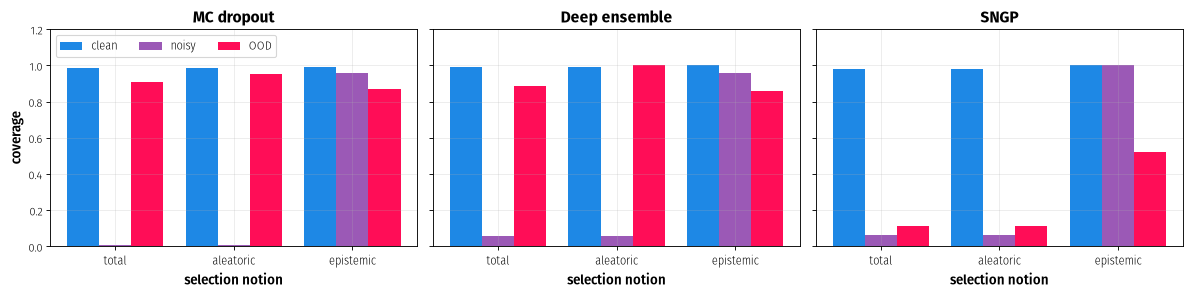

In [13]:
plot_coverage(results, {"clean": BLUE, "noisy": PURPLE, "OOD": RED})

Decision regions for the total uncertainty. Top: normal prediction. Bottom: selective prediction (gray = abstain). Crosses are accepted wrong labels, black circles are accepted OOD points.

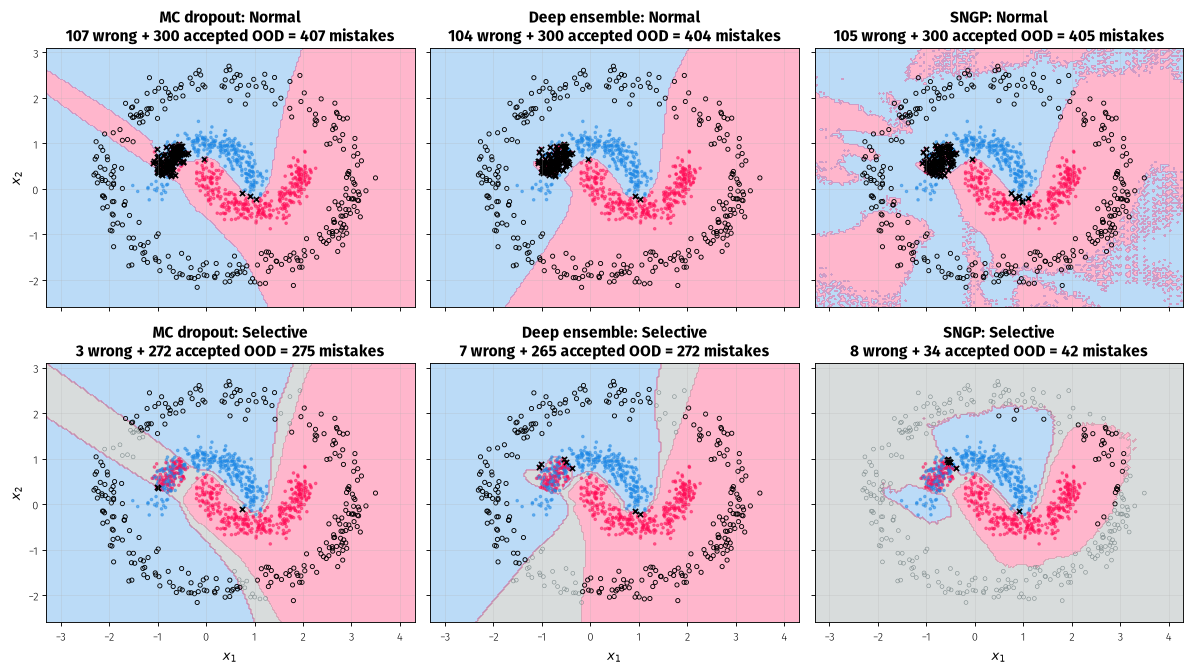

In [14]:
def plot_before_after(models, results, labels, xlim, ylim):
    xx, yy = np.meshgrid(np.linspace(*xlim, 200), np.linspace(*ylim, 160))
    grid = np.c_[xx.ravel(), yy.ravel()]
    fig, axes = plt.subplots(2, len(models), figsize=(5 * len(models), 8.5), sharex=True, sharey=True)
    for j, (name, model) in enumerate(models.items()):
        for i, kind in enumerate(["Normal", "Selective"]):
            ax = axes[i, j]
            res = results[name, "total"]
            res = as_normal(res) if i == 0 else res
            g = run(make_selective(model, "total", np.inf if i == 0 else THRESHOLDS["total"]), grid)
            ax.contourf(xx, yy, np.where(g.accepted, g.pred, 2).reshape(xx.shape), levels=[-0.5, 0.5, 1.5, 2.5],
                        colors=[BLUE, RED, GRAY], alpha=0.3)
            for s, r in res.items():
                x = sets[s]
                if s in labels:
                    ax.scatter(*x.T, c=np.where(labels[s] == 1, RED, BLUE), s=5, alpha=0.5)
                    wrong = r.accepted & (r.pred != labels[s])
                    ax.scatter(*x[wrong].T, marker="x", color="black", s=22)
                else:
                    ax.scatter(*x[~r.accepted].T, facecolors="none", edgecolors=GRAY, s=12, linewidths=0.5)
                    ax.scatter(*x[r.accepted].T, facecolors="none", edgecolors="black", s=14, linewidths=0.8)
            wrong, ood = mistakes(res, labels)
            ax.set_title(f"{name}: {kind}\n{wrong} wrong + {ood} accepted OOD = {wrong + ood} mistakes")
    for ax in axes[-1]:
        ax.set_xlabel("$x_1$")
    for ax in axes[:, 0]:
        ax.set_ylabel("$x_2$")
    plt.tight_layout()
    plt.show()


plot_before_after(models, results, labels, XLIM, YLIM)

Mistakes per method, normal prediction versus selective prediction with each notion.

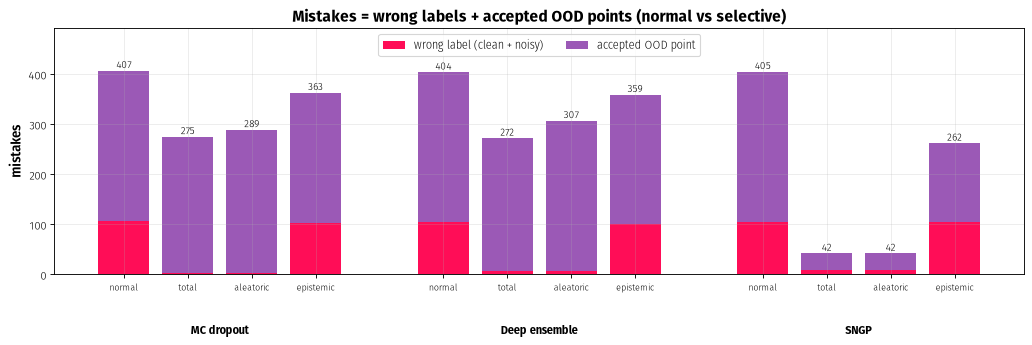

In [15]:
plot_mistakes(results, labels)

Accuracy on the accepted clean and noisy points as a function of coverage. The dashed line is normal prediction; dots mark the chosen thresholds.

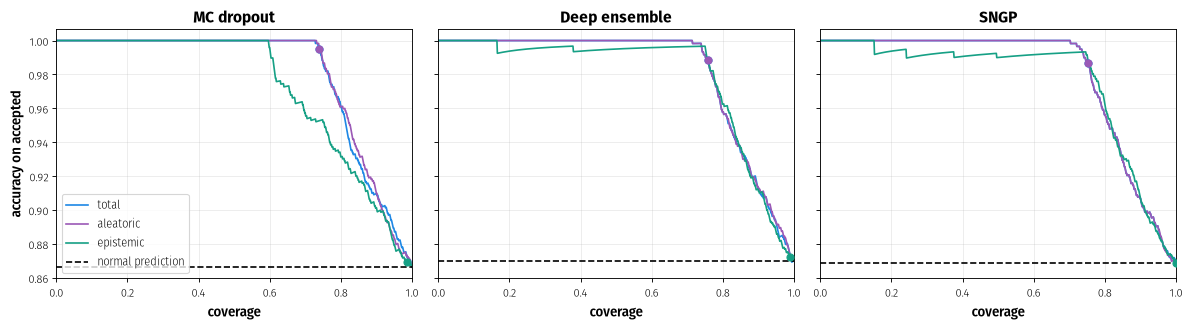

In [16]:
plot_acc_cov(results, labels)